# PilotNet ANN-SDNN conversion example

The ANN-SDNN conversion tool performs post-training conversion of full-precision pre-trained ANNs with ReLU activation to a fixed-precision Sigma-Delta ReLU network. The Sigma-Delta network is trainable with backpropagation. The conversion ensures a very minimal drop in performance of the resulting Sigma-Delta network and thus may be used without any fine-tuning.

The conversion tool is built on top of `lava-dl.slayer` tools and is available as `lava-dl.conversion`.

PilotNet is a deep network that predicts steering angle of a car based on its dashboard view. Click [here](https://github.com/lava-nc/lava-dl/blob/main/tutorials/lava/lib/dl/slayer/pilotnet/train.ipynb) for more detail about PilotNet task and Sigma-Delta network.

In [1]:
import os
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn.functional as F

from lava.lib.dl import slayer
from lava.lib.dl import conversion

from train_ann import Network
from pilotnet_dataset import PilotNetDataset

# Load ANN Network

The PilotNet ANN was trained using the `Network` module in `train_ann.py` and the final trained network was saved in `Trained/network.pt`. Here we will simply load the ANN with the trained state dictionary and use the ANN for conversion.

In [2]:
device = torch.device('cuda')
net = Network()
net.load_state_dict(torch.load('Trained/network.pt'))

<All keys matched successfully>

In [3]:
visualization_set = PilotNetDataset(
    sequence=200,
    visualize=True,
    transform=transforms.Compose([
        transforms.Resize([66, 200]),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]),
)
visualization_loader = DataLoader(dataset=visualization_set, batch_size=1, shuffle=True, num_workers=8)

# Convert ANN to SDNN

Here we will make use of a generic `conversion.network.Network` container which is designed to easily add layers programatically using `add_block` method.

`lava-dl.conversion` provides `translator` module which contains methods to translate convolutional and dense ANN layers to `lava-dl.slayer` compatible form. Note that a `SigmaDeltaReLU` instance is used as the activation. It can be simply a `ReLU` activation in that case the conversion would simply be a quantized ANN with ReLU activation.

Since, in a Sigma-Delta there is a time difference, the Sigma-Delta layers are encapsulated by a `Delta` layer to perform the input encoding and a `Sigma` layer to perform the output decoding.

In [4]:
map_dense_block = conversion.translator.map_dense_block
map_conv_block = conversion.translator.map_conv_block
threshold = 0.1

# Empty network container
slayer_sdnn = conversion.network.Network()

# Delta encoding layer
activation = conversion.activation.Delta(threshold=threshold)
slayer_sdnn.add_block(activation)

# Convert ANN layer to Sigma-Delta layer one by one
for idx in range(0, 15, 3):
    activation = conversion.activation.SigmaDeltaReLU(threshold=threshold)
    slayer_sdnn.add_block(map_conv_block(conv=net.blocks[idx], bn=net.blocks[idx + 1], activation=activation))
slayer_sdnn.add_block(conversion.block.Flatten())
for idx in range(16, 25, 3):
    activation = conversion.activation.SigmaDeltaReLU(threshold=threshold)
    slayer_sdnn.add_block(map_dense_block(dense=net.blocks[idx], bn=net.blocks[idx + 1], activation=activation))

# Sigma decoding layer
activation = conversion.activation.Sigma()
slayer_sdnn.add_block(map_dense_block(dense=net.blocks[25], activation=activation))

# Register output of the network
slayer_sdnn.output_idx = [len(slayer_sdnn.blocks) - 1]
slayer_sdnn = slayer_sdnn.to(device)

### Sparsity evaluation method

The following function claculates the sparsity of each layer based on the output of each layer and its associated synapse type.

In [5]:
def get_sparsity(slayer_sdnn):
    ann_synops = []
    sdnn_synops = []
    ann_events = []
    sdnn_events = []
    for idx, (blk) in enumerate(slayer_sdnn.blocks):
        if idx == 0:
            continue
        inp = slayer_sdnn.buffer[idx - 1]
        if isinstance(blk, conversion.block.ConvBlock):
            synops = (np.prod(
                inp.shape) * np.prod(blk.synapse.weight.shape[:3]) / np.prod(blk.synapse.stride))
        elif isinstance(blk, conversion.block.DenseBlock):
            synops = np.prod(blk.synapse.weight.shape)
        else:
            continue
        ann_synops.append(synops)
        sdnn_synops.append(torch.sum(inp > 0) / torch.numel(inp) * synops)
        ann_events.append(torch.numel(slayer_sdnn.buffer[idx]))
        sdnn_events.append(torch.sum(slayer_sdnn.buffer[idx] > 0))

    act_sparsity = (sum(ann_events) / sum(sdnn_events)).item()
    syn_sparsity = (sum(ann_synops) / sum(sdnn_synops)).item()
    return act_sparsity, syn_sparsity

# Run inference

The `conversion.network.Network` network used to load the Sigma-Delta network additionally provides a couple of additional functionalities similar to `slayer_sdnn.eval()`:
* `slayer_sdnn.full_precision()` configures the network to run in full_precision with fake quantization.
* `slayer_sdnn.fixed_precision()` configures the network to run in fixed precision with integer computations and bit truncations as necessary.
    * `slayer_sdnn.fixed_precision(validate=True)` configures the network to run in fixed precision and validate the computation with the fake quantization computation. This mode can be crucial in catching variable overflow in fixed precision.
* The quantization and dequantization is handled automatically in fixed precision mode, i.e., `output = slayer_sdnn.forward(input)` behave the same irrespective of fixed precision or full precision mode.

The `conversion.network.Network` has a buffer based implementation. The buffer is only stored as necessary. The user can select to store the output of all layers in the buffer by calling `slayer_sdnn.store_all_buffer = True`. This will be used in this notebook to evaluate the sparsity of the network. It is also amenable to network distillation.

In [6]:
print('INT ANN model:')  # This is evaluated independently
print('Test  loss =     0.02406')

print(f'INT SDNN model:')
act_sparsity = []
syn_sparsity = []

stats = slayer.utils.LearningStats()
t_st = datetime.now()
for i, (input, ground_truth) in enumerate(visualization_loader, 0):
    slayer_sdnn.eval()
    slayer_sdnn.fixed_precision(validate=True)
    slayer_sdnn.store_all_buffer = True

    with torch.no_grad():
        input = input.to(device)
        ground_truth = ground_truth.to(device)

        output = slayer_sdnn.forward(input)

        stats.testing.num_samples += len(ground_truth)

        loss = F.mse_loss(output.flatten(), ground_truth.flatten())
        stats.testing.loss_sum += loss.cpu().data.item() * output.shape[0]

    time_elapsed = (datetime.now() - t_st).total_seconds()
    samples_sec = time_elapsed / (i + 1) / visualization_loader.batch_size

    print(f'\rIter:{i}, {samples_sec:.3f}sec/sample Test{str(stats).split("Test")[1].split("accuracy")[0]}', end='')

    act_sp, syn_sp = get_sparsity(slayer_sdnn)
    act_sparsity.append(act_sp)
    syn_sparsity.append(syn_sp)


INT ANN model:
Test  loss =     0.02406
INT SDNN model:
Iter:180, 0.402sec/sample Test  loss =     0.02312                          

In [7]:
print(f'Events Sparsity = {np.mean(act_sparsity):.2f} x')
print(f'Synops Sparsity = {np.mean(syn_sparsity):.2f} x')

Events Sparsity = 17.72 x
Synops Sparsity = 16.15 x


# Inference on a continuous sequence for visualization

In [8]:
outputs = []
gts = []
for idx in range(40, 60):
    input, gt = visualization_set[idx]
    output = slayer_sdnn(input[None].to(device))
    gts.append(gt.data.numpy().flatten())
    outputs.append(output.cpu().data.numpy().flatten())

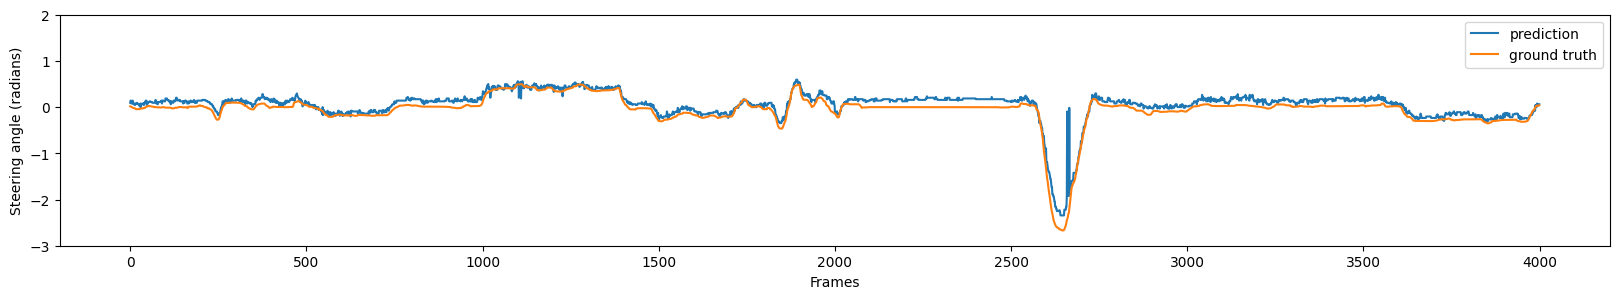

In [9]:
plt.figure(figsize=(20, 3))
plt.plot(np.concatenate(outputs), label='prediction')
plt.plot(np.concatenate(gts), label='ground truth')
plt.axis([None, None, -3, 2])

plt.ylabel('Steering angle (radians)')
plt.xlabel('Frames')
plt.legend()